#Notebook 8: Spatial Immune Architecture

This notebook clusters Visium spots using cell2location estimates, characterizes immune architechture along spatial regions, compares both lesions, and then saves the annotated objects

In [57]:
!pip install -q \
scanpy \
pandas \
numpy==2.0.2 \
squidpy \
matplotlib \
anndata \
igraph \
seaborn \
ptitprince

In [58]:
# -- Imports
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import igraph
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import ptitprince as pt

import anndata as ad
ad.settings.allow_write_nullable_strings = True

In [59]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [60]:
# -- Paths
project_path = Path("/content/drive/MyDrive/endo-immune-atlas")

input_path_346 = (
    project_path
    / "data"
    / "interim"
    / "spatial"
    / "BEME_346_cell2location.h5ad"
    )

input_path_355G = (
    project_path
    / "data"
    / "interim"
    / "spatial"
    / "BEME_355G_cell2location.h5ad"
    )

output_path_data = (project_path
                    / "data"
                    / "interim"
                    / "spatial"
                    )

output_path_results = (
    project_path
    / "results"
    / "spatial"
    / "immune_architecture"
    )

output_path_figures = (
    project_path
    / "figures"
    / "spatial"
    / "immune_architecture")

output_path_data.mkdir(parents=True, exist_ok=True)
output_path_results.mkdir(parents=True, exist_ok=True)
output_path_figures.mkdir(parents=True, exist_ok=True)

In [61]:
# -- COLOR PALETTES
spatial_palette  = [
    "#E69F00",
    "#00538A",
    "#BFBFBF",
    "#969696",
    "#009E73",
    "#6E6E6E",
    "#D55E00",
    "#A6BDD7",
    "#404040",
    "#98B6B1",
    "#D2D68D",
    "#32CBFF",
]

immune_palette_map = {
    "Immune-high": "#A41623",
    "Immune-moderate-high": "#E67E22",
    "Immune-moderate": "#F6C65B",
    "Immune-moderate-low": "#4C78A8",
    "Immune-low": "#7A7A7A",
    "Immune-poor": "#D9D9D9",
}

immune_class_order = [
    "Immune-high",
    "Immune-moderate-high",
    "Immune-moderate",
    "Immune-moderate-low",
    "Immune-low",
    "Immune-poor",
]

In [62]:
# -- Parameters
cluster_key = "leiden_0.4"

In [63]:
# -- Import objects
adata_346 = sc.read_h5ad(input_path_346)
adata_355G = sc.read_h5ad(input_path_355G)

print(adata_346)
print(adata_355G)

AnnData object with n_obs × n_vars = 1388 × 22220
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'sample_id', 'gsm_id', 'tissue_type', 'condition', 'lesion_site', '_indices', '_scvi_batch', '_scvi_labels', 'meanscell_abundance_w_sf_B', 'meanscell_abundance_w_sf_CD4 T', 'meanscell_abundance_w_sf_CD8 T', 'meanscell_abundance_w_sf_DC', 'meanscell_abundance_w_sf_Mono-C', 'meanscell_abundance_w_sf_Mono-NC', 'meanscell_abundance_w_sf_NK-CD16+', 'meanscell_abundance_w_sf_NK-CD16-', 'meanscell_abundance_w_sf_TRM', 'meanscell_abundance_w_sf_Treg', 'meanscell_abundance_w_sf_γδ T', 'Total immune'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod', 'spatial'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'
AnnData object with n_obs × n_vars = 1960 × 22220
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'sample_id', 'gsm_id', 'tissue_type', 'condition',

In [64]:
#===========================================================
# FUNCTIONS
#===========================================================

def prepare_spatial_regions(
    adata,
    library_id,
    leiden_resolution=0.4
):
    abundance_key = "q05_cell_abundance_w_sf"

    if abundance_key not in adata.obsm:
        raise KeyError(
            f"{abundance_key} is missing from {library_id}."
        )

    # -- Copy abundance estimates and remove cell2location prefixes
    abundance = adata.obsm[abundance_key].copy()

    abundance.columns = [
        column.split("_sf_", 1)[-1]
        for column in abundance.columns
    ]

    cell_columns = abundance.columns.tolist()

    # -- Add clean cell-type abundance columns to obs
    adata.obs[cell_columns] = abundance

    # -- Neighbors using cell2location abundance estimates
    sc.pp.neighbors(
        adata,
        use_rep=abundance_key,
        n_neighbors=15
    )

    # -- Compare Leiden resolutions
    for resolution in [0.2, 0.4, 0.6, 0.8]:

        sc.tl.leiden(
            adata,
            resolution=resolution,
            flavor="igraph",
            n_iterations=2,
            random_state=0,
            key_added=f"leiden_{resolution}"
        )

    cluster_key = f"leiden_{leiden_resolution}"

    adata.obs["region_cluster"] = (
        adata.obs[cluster_key]
        .astype("category")
    )

    # -- UMAP from abundance-based neighbors
    sc.tl.umap(
        adata,
        min_dist=0.3,
        spread=1,
        random_state=0
    )

    # -- Mean immune abundance per spatial region
    region_means = (
        adata.obs
        .groupby(
            cluster_key,
            observed=True
        )[cell_columns]
        .mean()
    )

    region_means["total_immune"] = (
        region_means[cell_columns]
        .sum(axis=1)
    )

    # -- Total immune abundance per spot
    adata.obs["total_immune_spot_level"] = (
        adata.obs[cell_columns]
        .sum(axis=1)
    )

    # -- Region-level abundance assigned back to spots
    adata.obs["total_immune_region_level"] = (
        adata.obs[cluster_key]
        .astype(str)
        .map(region_means["total_immune"])
    )

    print(
        f"{library_id}: "
        f"{adata.obs[cluster_key].nunique()} spatial regions"
    )

    return adata, region_means, cell_columns


def plot_region_clustering(
    adata,
    library_id
):
    # -- Spatial Leiden resolutions
    sq.pl.spatial_scatter(
        adata,
        color=[
            "leiden_0.2",
            "leiden_0.4",
            "leiden_0.6",
            "leiden_0.8"
        ],
        ncols=2,
        size=1.5,
        img=False
    )

    plt.savefig(
        output_path_figures
        / f"08_{library_id}_leiden_clusters.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

    # -- UMAP of abundance-based clusters
    with mpl.rc_context(
        {
            "axes.facecolor": "white",
            "figure.figsize": [8, 8]
        }
    ):

        sc.pl.umap(
            adata,
            color="leiden_0.4",
            size=30,
            legend_loc="on data",
            legend_fontsize=16,
            palette=spatial_palette,
            show=False
        )

    plt.savefig(
        output_path_figures
        / f"08_{library_id}_spatial_umap.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()


def plot_spatial_architecture(
    adata,
    cell_columns,
    library_id
):
    plot_columns = (
        cell_columns
        + ["total_immune_spot_level"]
    )

    ncols = 4

    nrows = int(
        np.ceil(
            len(plot_columns)
            / ncols
        )
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(20, nrows * 4)
    )

    axes = np.atleast_1d(
        axes
    ).flatten()

    for ax, column in zip(
        axes,
        plot_columns
    ):

        sq.pl.spatial_scatter(
            adata,
            color=column,
            cmap="magma",
            img=True,
            size=1.5,
            ax=ax
        )

        ax.set_title(
            "Total Immune"
            if column == "total_immune_spot_level"
            else column,
            fontsize=11
        )

    # -- Hide unused panels
    for ax in axes[
        len(plot_columns):
    ]:
        ax.axis("off")

    fig.subplots_adjust(
        wspace=0.05,
        hspace=0.25
    )

    plt.savefig(
        output_path_figures
        / f"08_{library_id}_spatial_architecture.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()


def plot_region_abundance(
    region_means,
    cell_columns,
    library_id
):
    # -- Total immune abundance by region
    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    region_means["total_immune"].plot.bar(
        ax=ax
    )

    ax.set_title(
        f"{library_id}: Total Immune Abundance"
    )

    ax.set_ylabel(
        "Mean immune abundance"
    )

    ax.set_xlabel(
        "Spatial region"
    )

    plt.tight_layout()

    plt.savefig(
        output_path_figures
        / f"08_{library_id}_total_immune_abundance.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

    # -- Cell-type abundance heatmap
    cluster_grid = sns.clustermap(
        region_means[cell_columns],
        row_cluster=True,
        col_cluster=False,
        cmap="RdBu_r"
    )

    cluster_grid.fig.suptitle(
        f"{library_id}: Mean Cell Abundance by Region",
        y=1.02
    )

    cluster_grid.savefig(
        output_path_figures
        / f"08_{library_id}_cell_abundance_heatmap.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close(
        cluster_grid.fig
    )


def assign_immune_classes(
    adata,
    region_means,
    region_class_map,
    library_id,
    cluster_key="leiden_0.4"
):
    # -- Confirm that the manual map matches the current clusters
    observed_regions = set(
        adata.obs[cluster_key]
        .astype(str)
        .unique()
    )

    mapped_regions = set(
        region_class_map.keys()
    )

    if observed_regions != mapped_regions:

        missing = sorted(
            observed_regions
            - mapped_regions
        )

        extra = sorted(
            mapped_regions
            - observed_regions
        )

        raise ValueError(
            f"{library_id} region map does not match the clustering. "
            f"Missing mappings: {missing}; "
            f"extra mappings: {extra}"
        )

    # -- Map spatial regions to immune classes
    immune_class = (
        adata.obs[cluster_key]
        .astype(str)
        .map(region_class_map)
    )

    if immune_class.isna().any():

        missing_regions = (
            adata.obs.loc[
                immune_class.isna(),
                cluster_key
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            f"{library_id} has unmapped regions: "
            f"{missing_regions}"
        )

    # -- Biological order used for tables and downstream analysis
    observed_class_order = [
        label
        for label in immune_class_order
        if label in immune_class.unique()
    ]

    adata.obs[
        "tissue_level_immune_class"
    ] = pd.Categorical(
        immune_class,
        categories=observed_class_order,
        ordered=True
    )

    # -- Remove any old color metadata
    adata.uns.pop(
        "tissue_level_immune_class_colors",
        None
    )

    adata.uns[
        "tissue_level_immune_class_colors"
    ] = [
        immune_palette_map[label]
        for label in observed_class_order
    ]

    # -- Add immune classes to the region-level table
    region_class = (
        adata.obs
        .groupby(
            cluster_key,
            observed=True
        )[
            "tissue_level_immune_class"
        ]
        .first()
    )

    region_means[
        "tissue_level_immune_class"
    ] = region_class.reindex(
        region_means.index
    )

    print(
        f"\n{library_id} immune classes:"
    )

    print(
        adata.obs[
            "tissue_level_immune_class"
        ]
        .value_counts(
            dropna=False
        )
    )

    print(
        "Biological class order:",
        observed_class_order
    )

    print(
        "Color pairing (by category order):",
        dict(
            zip(
                observed_class_order,
                adata.uns[
                    "tissue_level_immune_class_colors"
                ]
            )
        )
    )

    return adata, region_means


def validate_immune_classes(
    adata,
    region_means,
    library_id
):
    class_col = (
        "tissue_level_immune_class"
    )

    # -- Region-level validation graph
    plot_df = (
        region_means
        .sort_values(
            "total_immune"
        )
        .copy()
    )

    region_colors = [
        immune_palette_map[
            str(label)
        ]
        for label in plot_df[class_col]
    ]

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.bar(
        plot_df.index.astype(str),
        plot_df["total_immune"],
        color=region_colors
    )

    ax.set_xlabel(
        "Spatial region"
    )

    ax.set_ylabel(
        "Mean immune abundance"
    )

    ax.set_title(
        f"{library_id}: Validation of Immune Classes"
    )

    plt.tight_layout()

    plt.savefig(
        output_path_figures
        / f"08_{library_id}_immune_class_validation.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

    # -- Spatial immune-class plot (scanpy instead of squidpy --
    # -- sq.pl.spatial_scatter was not respecting palette/colors)
    sc.pl.embedding(
        adata,
        basis="spatial",
        color=class_col,
        palette=immune_palette_map,
        size=60,
        show=False
    )

    plt.title(
        f"Immune Regions: {library_id}"
    )

    plt.savefig(
        output_path_figures
        / f"08_{library_id}_spatial_immune_classes.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.show()

    plt.close()


def make_region_summary(
    region_means,
    cell_columns,
    library_id
):
    summary = region_means[
        [
            "tissue_level_immune_class",
            "total_immune"
        ]
    ].copy()

    summary[
        "dominant_cell_type"
    ] = (
        region_means[
            cell_columns
        ]
        .idxmax(axis=1)
    )

    summary = summary.sort_values(
        "total_immune",
        ascending=False
    )

    summary.index.name = (
        "region_cluster"
    )

    summary.insert(
        0,
        "library_id",
        library_id
    )

    return summary.reset_index()

###TISSUE 1: BEME_346

In [65]:
#===========================================================
# TISSUE #1: BEME_346
#===========================================================

adata_346, region_means_346, cell_columns_346 = (
    prepare_spatial_regions(
        adata_346,
        library_id="BEME_346"
    )
)

plot_region_clustering(
    adata_346,
    library_id="BEME_346"
)

plot_spatial_architecture(
    adata_346,
    cell_columns=cell_columns_346,
    library_id="BEME_346"
)

plot_region_abundance(
    region_means_346,
    cell_columns=cell_columns_346,
    library_id="BEME_346"
)

BEME_346: 10 spatial regions



BEME_346 immune classes:
tissue_level_immune_class
Immune-low              366
Immune-high             296
Immune-poor             286
Immune-moderate-low     283
Immune-moderate-high    157
Name: count, dtype: int64
Biological class order: ['Immune-high', 'Immune-moderate-high', 'Immune-moderate-low', 'Immune-low', 'Immune-poor']
Color pairing (by category order): {'Immune-high': '#A41623', 'Immune-moderate-high': '#E67E22', 'Immune-moderate-low': '#4C78A8', 'Immune-low': '#7A7A7A', 'Immune-poor': '#D9D9D9'}


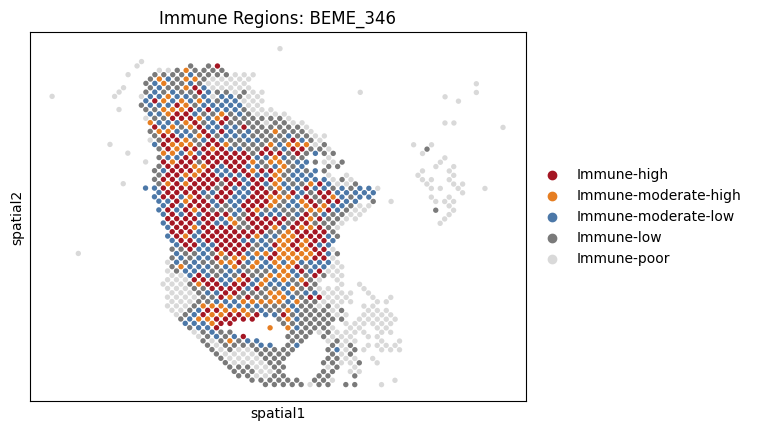

,region_cluster,library_id,tissue_level_immune_class,total_immune,dominant_cell_type
0,9,BEME_346,Immune-high,96.114037,CD8 T
1,0,BEME_346,Immune-high,93.843414,CD8 T
2,6,BEME_346,Immune-moderate-high,64.286507,CD8 T
3,1,BEME_346,Immune-moderate-low,54.467182,CD4 T
4,8,BEME_346,Immune-moderate-low,45.566067,CD8 T
5,4,BEME_346,Immune-low,38.695740,CD8 T
6,2,BEME_346,Immune-low,24.591093,CD4 T
7,3,BEME_346,Immune-low,15.260765,CD8 T
8,5,BEME_346,Immune-poor,7.338196,CD4 T
9,7,BEME_346,Immune-poor,1.466542,CD8 T


In [66]:
tissue_346_region_class = {
    "0": "Immune-high",
    "1": "Immune-moderate-low",
    "2": "Immune-low",
    "3": "Immune-low",
    "4": "Immune-low",
    "5": "Immune-poor",
    "6": "Immune-moderate-high",
    "7": "Immune-poor",
    "8": "Immune-moderate-low",
    "9": "Immune-high"
}

adata_346, region_means_346 = assign_immune_classes(
    adata_346,
    region_means=region_means_346,
    region_class_map=tissue_346_region_class,
    library_id="BEME_346"
)

validate_immune_classes(
    adata_346,
    region_means=region_means_346,
    library_id="BEME_346"
)

summary_346 = make_region_summary(
    region_means_346,
    cell_columns=cell_columns_346,
    library_id="BEME_346"
)

display(summary_346)

## TISSUE 2: BEME_355G

In [67]:
adata_355G, region_means_355G, cell_columns_355G = (
    prepare_spatial_regions(
        adata_355G,
        library_id="BEME_355G"
    )
)

plot_region_clustering(
    adata_355G,
    library_id="BEME_355G"
)

plot_spatial_architecture(
    adata_355G,
    cell_columns=cell_columns_355G,
    library_id="BEME_355G"
)

plot_region_abundance(
    region_means_355G,
    cell_columns=cell_columns_355G,
    library_id="BEME_355G"
)

BEME_355G: 12 spatial regions



BEME_355G immune classes:
tissue_level_immune_class
Immune-poor             593
Immune-low              413
Immune-moderate-low     347
Immune-moderate-high    241
Immune-high             193
Immune-moderate         173
Name: count, dtype: int64
Biological class order: ['Immune-high', 'Immune-moderate-high', 'Immune-moderate', 'Immune-moderate-low', 'Immune-low', 'Immune-poor']
Color pairing (by category order): {'Immune-high': '#A41623', 'Immune-moderate-high': '#E67E22', 'Immune-moderate': '#F6C65B', 'Immune-moderate-low': '#4C78A8', 'Immune-low': '#7A7A7A', 'Immune-poor': '#D9D9D9'}


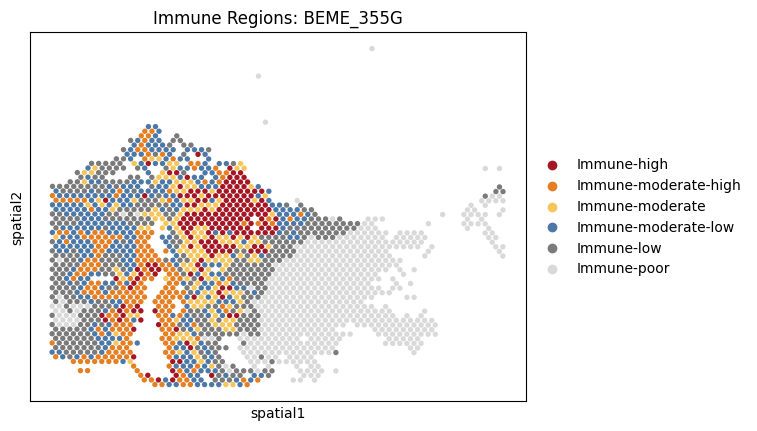

,region_cluster,library_id,tissue_level_immune_class,total_immune,dominant_cell_type
0,11,BEME_355G,Immune-high,208.193787,CD8 T
1,3,BEME_355G,Immune-moderate-high,130.506668,CD4 T
2,10,BEME_355G,Immune-high,119.691902,CD8 T
3,2,BEME_355G,Immune-moderate-low,78.335983,CD8 T
4,9,BEME_355G,Immune-moderate,75.915672,CD8 T
5,4,BEME_355G,Immune-moderate-low,51.900311,CD4 T
6,1,BEME_355G,Immune-low,43.511616,CD8 T
7,7,BEME_355G,Immune-low,25.933357,CD4 T
8,5,BEME_355G,Immune-low,20.652370,CD8 T
9,0,BEME_355G,Immune-poor,4.965096,CD8 T


In [68]:
tissue_355G_region_class = {
    "0": "Immune-poor",
    "1": "Immune-low",
    "2": "Immune-moderate-low",
    "3": "Immune-moderate-high",
    "4": "Immune-moderate-low",
    "5": "Immune-low",
    "6": "Immune-poor",
    "7": "Immune-low",
    "8": "Immune-poor",
    "9": "Immune-moderate",
    "10": "Immune-high",
    "11": "Immune-high"
}

adata_355G, region_means_355G = assign_immune_classes(
    adata_355G,
    region_means=region_means_355G,
    region_class_map=tissue_355G_region_class,
    library_id="BEME_355G"
)

validate_immune_classes(
    adata_355G,
    region_means=region_means_355G,
    library_id="BEME_355G"
)

summary_355G = make_region_summary(
    region_means_355G,
    cell_columns=cell_columns_355G,
    library_id="BEME_355G"
)

display(summary_355G)

In [69]:
# -- Lesion comparison
df346 = adata_346.obs[
    [
        "total_immune_region_level",
        "total_immune_spot_level",
        "tissue_level_immune_class"
    ]
].copy()

df346["library_id"] = "BEME_346"

df355G = adata_355G.obs[
    [
        "total_immune_region_level",
        "total_immune_spot_level",
        "tissue_level_immune_class"
    ]
].copy()

df355G["library_id"] = "BEME_355G"

comparison_df = pd.concat(
    [df346, df355G],
    ignore_index=True
)

comparison_df["tissue_level_immune_class"] = pd.Categorical(
    comparison_df["tissue_level_immune_class"].astype(str),
    categories=immune_class_order,
    ordered=True
)

display(comparison_df.head())


,total_immune_region_level,total_immune_spot_level,tissue_level_immune_class,library_id
0,93.843414,95.522377,Immune-high,BEME_346
1,93.843414,103.314102,Immune-high,BEME_346
2,54.467182,64.713219,Immune-moderate-low,BEME_346
3,15.260765,21.414412,Immune-low,BEME_346
4,7.338196,9.838631,Immune-poor,BEME_346


In [70]:
# -- Immune class proportions by lesion
immune_class_proportions = (
    comparison_df
    .groupby("library_id", observed=True)[
        "tissue_level_immune_class"
    ]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=immune_class_order, fill_value=0)
)

immune_class_proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=[
        immune_palette_map[label]
        for label in immune_class_order
    ],
)

plt.ylabel("Proportion of spots")
plt.xlabel("Lesion")

plt.legend(
    title="Immune class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    output_path_figures / "08_lesion_immune_class_proportions.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

display(immune_class_proportions)

tissue_level_immune_class,Immune-high,Immune-moderate-high,Immune-moderate,Immune-moderate-low,Immune-low,Immune-poor
library_id,,,,,,
BEME_346,0.213256,0.113112,0.000000,0.203890,0.263689,0.206052
BEME_355G,0.098469,0.122959,0.088265,0.177041,0.210714,0.302551


In [79]:
# -- Immune abundance distributions across classes

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5.5),
    sharey=True
)

for ax, plot_df, title in zip(
    axes,
    [
        df346,
        df355G
    ],
    [
        "BEME_346",
        "BEME_355G"
    ]
):

    pt.RainCloud(
        data=plot_df,
        x="tissue_level_immune_class",
        y="total_immune_spot_level",
        hue="tissue_level_immune_class",
        order=immune_class_order,
        hue_order=immune_class_order,
        palette=immune_palette_map,
        orient="h",
        width_viol=0.5,
        width_box=0.5,
        move=0.2,
        alpha=0.65,
        dodge=False,
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=14
    )

    ax.set_xscale(
        "log"
    )

    ax.set_xlabel(
        "Total immune abundance"
    )

    ax.legend(
        [],
        [],
        frameon=False
    )

axes[0].set_ylabel(
    "Immune class"
)

axes[1].set_ylabel(
    ""
)

plt.tight_layout()

plt.savefig(
    output_path_figures
    / "08_lesion_immune_abundance_raincloud.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):


In [72]:
# -- Save results
region_summary = pd.concat(
    [summary_346, summary_355G],
    ignore_index=True
)

region_summary.to_csv(
    output_path_results / "08_spatial_region_summary.csv",
    index=False
)

immune_class_proportions.to_csv(
    output_path_results / "08_immune_class_proportions.csv"
)

comparison_df.to_csv(
    output_path_results / "08_spot_level_immune_architecture.csv",
    index=False
)

output_file_346 = (
    output_path_data
    / "BEME_346_spatial_immune_architecture.h5ad"
)

output_file_355G = (
    output_path_data
    / "BEME_355G_spatial_immune_architecture.h5ad"
)

adata_346.write_h5ad(output_file_346)
adata_355G.write_h5ad(output_file_355G)

saved_346 = sc.read_h5ad(output_file_346, backed="r")
saved_355G = sc.read_h5ad(output_file_355G, backed="r")

print(saved_346)
print(saved_355G)

saved_346.file.close()
saved_355G.file.close()

print("Saved:")
print(" - BEME_346_spatial_immune_architecture.h5ad")
print(" - BEME_355G_spatial_immune_architecture.h5ad")
print(" - 08_spatial_region_summary.csv")
print(" - 08_immune_class_proportions.csv")
print(" - 08_spot_level_immune_architecture.csv")

AnnData object with n_obs × n_vars = 1388 × 22220 backed at '/content/drive/MyDrive/endo-immune-atlas/data/interim/spatial/BEME_346_spatial_immune_architecture.h5ad'
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'sample_id', 'gsm_id', 'tissue_type', 'condition', 'lesion_site', '_indices', '_scvi_batch', '_scvi_labels', 'meanscell_abundance_w_sf_B', 'meanscell_abundance_w_sf_CD4 T', 'meanscell_abundance_w_sf_CD8 T', 'meanscell_abundance_w_sf_DC', 'meanscell_abundance_w_sf_Mono-C', 'meanscell_abundance_w_sf_Mono-NC', 'meanscell_abundance_w_sf_NK-CD16+', 'meanscell_abundance_w_sf_NK-CD16-', 'meanscell_abundance_w_sf_TRM', 'meanscell_abundance_w_sf_Treg', 'meanscell_abundance_w_sf_γδ T', 'Total immune', 'B', 'CD4 T', 'CD8 T', 'DC', 'Mono-C', 'Mono-NC', 'NK-CD16+', 'NK-CD16-', 'TRM', 'Treg', 'γδ T', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'region_cluster', 'total_immune_spot_level', 'total_immune_region_level', 'tissue_level_immune_class'
    var: 'gene_ids',